Computing p-values from variable importance
=====================================

This is an *VariantSpark* example notebook.


One of the main applications of VariantSpark is discovery of genomic variants correlated with a response variable (e.g. case vs control) using random forest gini importance.

The `chr22_1000.vcf` is a very small sample of the chromosome 22 VCF file from the 1000 Genomes Project.

`chr22-labels.csv` is a CSV file with sample response variables (labels). In fact the labels directly represent the number of alternative alleles for each sample at a specific genomic position. E.g.: column 22_16050408 has labels derived from variants in chromosome 22 position 16050408. We would expect then that position 22:16050408 in the VCF file is strongly correlated with the label 22_16050408.

Both data sets are located in the `..\data` directory.

This notebook demonstrates how to correctly get the p-values for each of the SNPs and their significant ones based on a *VariantSpark* model.

Step 1: Import VariantSpark and Matplotlib. Create a spark session with VariantSpark jar attached

In [1]:
import varspark as vs
from pyspark.sql import SparkSession
spark = vs.configure_spark(
    SparkSession.builder.config('spark.jars', vs.find_jar())
).getOrCreate()
from matplotlib import pyplot as plt

26/02/10 16:09:15 WARN Utils: Your hostname, RADON-BH resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/02/10 16:09:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/02/10 16:09:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/10 16:09:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Step 2: Create a `VarsparkContext` using `SparkSession` object (here injected as `spark`):

In [2]:
vc = vs.VarsparkContext(spark, silent=True)

Step 3: Load genotypes from a sample `.vcf` file.

In [3]:
genotypes = vc.import_vcf('../../data/chr22_1000.vcf')

../../data/chr22_1000.vcf is loading to spark RDD, isBGZFile: false


Step 4: Load the label corresponding to position 22:16050408.

In [4]:
labels = vc.load_label('../../data/chr22-labels.csv', col_name='22_16050408')

Step 5: Build the random forest model with `label.22_16050408` as the respose variable.

In [5]:
rf_model = vs.RandomForestModel(vc, mtry_fraction=0.10, min_node_size =5, max_depth=10, seed=13)
rf_model.fit_trees(genotypes, labels, n_trees=300, batch_size=50)

Step 6: Display the results: print OOB error calculated variable importance.

In [6]:
print("OOB error: %s" % rf_model.oob_error())
ia = rf_model.importance_analysis()
ia.variable_importance().sort_values(by='importance', ascending=False).head(10)

OOB error: 0.0027472527472527475


,variant_id,importance,splitCount
1242,22_16050408_T_C,42.058020,265
1740,22_16050678_C_T,31.112623,159
1492,22_16051480_T_C,19.919253,81
1743,22_16052838_T_A,13.774625,59
248,22_16051107_C_A,13.546839,57
497,22_16051882_C_T,12.577229,41
499,22_16053197_G_T,11.524518,42
1246,22_16053435_G_T,11.213713,36
4,22_16053509_A_G,10.048770,28
1245,22_16052656_T_C,9.794987,43


Step 7: Get the fdr calculation class from the VariantSpark model

In [7]:
fdrCalc = rf_model.get_lfdr()

Step 8: Visualize the distribution of importances based on the number of splits for a variable to be included. These distributions can take many shapes but the goal here is that there is one big *unimodal distribution*. In this case, setting the threshold to `2` looks the best.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


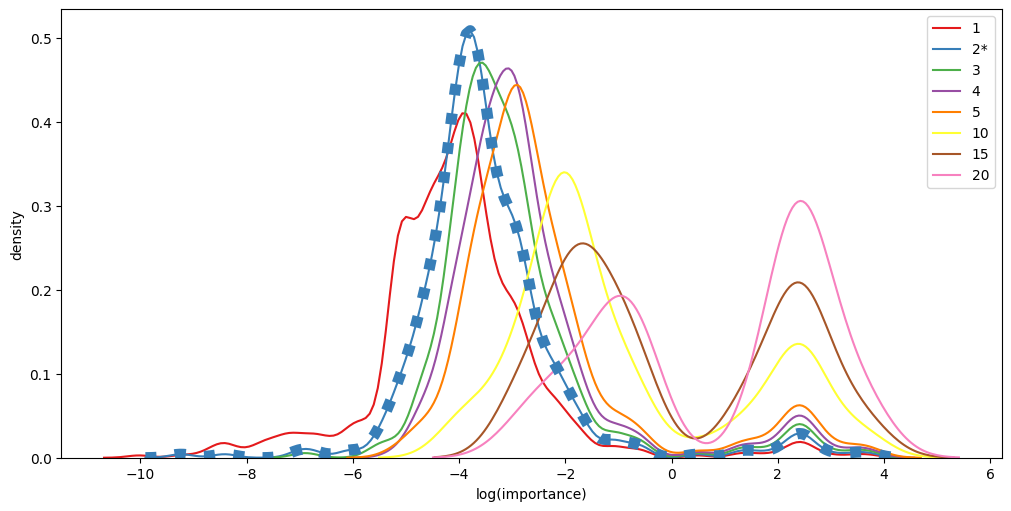

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot_log_densities(ax1, cutoff_list=[1, 2, 3, 4, 5, 10, 15, 20], find_automatic_best=True)
plt.show()

Step 9: This is a sanity check to visualize the splitcount was correct and consistent. (optional)

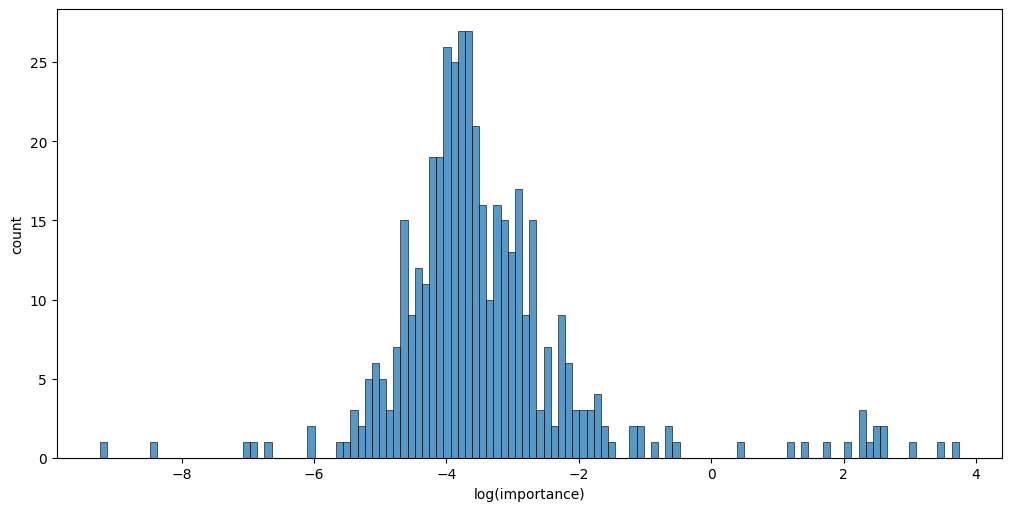

In [9]:
fig, ax2 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot_log_hist(ax2, split_count=2)
plt.show()

Step 10: Compute the p-values, their significance, and the expected false discovery rate (FDR).

In [10]:
pvalsDF, fdr = fdrCalc.compute_fdr(countThreshold = 2, local_fdr_cutoff = 0.05)
pvalsDF, fdr

(          variant_id  logImportance        pvalue  is_significant
 0    22_17692227_C_T      -9.235210  1.000000e+00           False
 1    22_17685351_C_A      -8.416335  1.000000e+00           False
 2    22_17753699_G_A      -7.043875  1.000000e+00           False
 3    22_16052684_A_C      -6.899779  9.999999e-01           False
 4    22_17706567_C_T      -6.711710  9.999994e-01           False
 ..               ...            ...           ...             ...
 424  22_16051107_C_A       2.606153  1.218060e-08            True
 425  22_16052838_T_A       2.622828  1.125689e-08            True
 426  22_16051480_T_C       2.991687  1.880384e-09            True
 427  22_16050678_C_T       3.437614  1.926168e-10            True
 428  22_16050408_T_C       3.739050  3.843426e-11            True
 
 [429 rows x 4 columns],
 0.001050147284833347)

Step 11: Visualize that the distribution (purple bars), fits the fitted distribution (red line). The "C" (orange) should fall on the right of the red distribution. And the local fdr (blue) crossing the black line (cutoff threshold) is on the right from 'C'. (optional but encouraged)

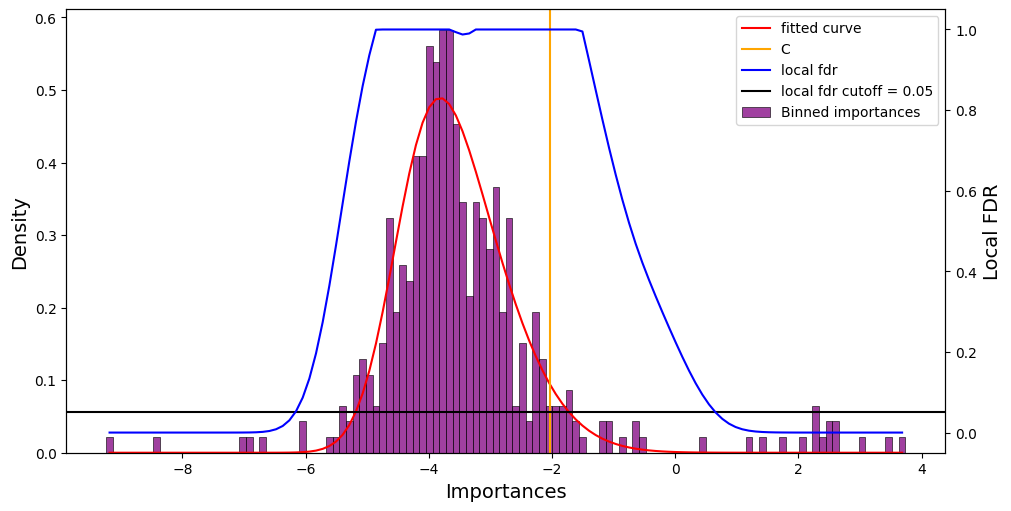

In [11]:
fig, ax3 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot(ax3)
plt.show()